# Setup - Imports and Environment

In [1]:
# --- Standard & Third-Party Imports ---
from __future__ import absolute_import, division, print_function
import os
import sys
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import cv2
import torch
from torchvision import transforms
from torchmetrics import SpectralAngleMapper, StructuralSimilarityIndexMeasure

# --- Jupyter Magic Commands ---
%matplotlib inline
%load_ext autoreload
%reload_ext autoreload
%autoreload 2

# --- Add Project Root to Python Path ---
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)
    print(f"Added to path: {project_root}")

# --- Local Module Imports ---
from hsiData import HyperSkinData
from helpers import metrics
from hsiData.models.reconstruction import MST_Plus_Plus, HSCNN_Plus, hrnet

Added to path: /home/gabriel/Hyper-Skin-2023


/home/gabriel/.venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:62: FutureWarning: Importing `StructuralSimilarityIndexMeasure` from `torchmetrics` was deprecated and will be removed in 2.0. Import `StructuralSimilarityIndexMeasure` from `torchmetrics.image` instead.
  _future_warning(


# Configuration

In [2]:
# --- Device Configuration ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# --- Path Configuration (using os.path.join for robustness) ---
data_dir = '/mnt/data/HyperSkin2023'
project_dir = '/home/gabriel/Hyper-Skin-2023'

rgbvis_dir = os.path.join(data_dir, 'Hyper-Skin(RGB, VIS)')
pretrained_dir = os.path.join(project_dir, 'Models', 'RGB-VIS')
results_dir = os.path.join(project_dir, 'evaluationResults')

# Directories for test data
rgb_dir = os.path.join(rgbvis_dir, 'test', 'RGB')
vis_dir = os.path.join(rgbvis_dir, 'test', 'VIS')

# --- Evaluation Configuration ---
BATCH_SIZE = 1
MODEL_NAME = 'MST_Plus_Plus'
BAND_WAVELENGTHS = np.arange(400, 710, 10) # 31 bands from 400nm to 700nm

# --- Output File Configuration ---
os.makedirs(results_dir, exist_ok=True)
results_file = os.path.join(results_dir, f'results_{MODEL_NAME.lower()}.pkl')
print(f"Results will be saved to/loaded from: {results_file}")

Using device: cuda
Results will be saved to/loaded from: /home/gabriel/Hyper-Skin-2023/evaluationResults/results_mst_plus_plus.pkl


# Data & Model Loading

In [3]:
# --- Load Dataset ---
test_transform = transforms.Compose([
    transforms.ToTensor()
])
test_dataset = HyperSkinData.Load(
    hsi_dir=vis_dir,
    rgb_dir=rgb_dir,
    transform=test_transform
)
test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True if device == 'cuda' else False
)
print(f"Test dataset loaded with {len(test_dataset)} samples.")

# --- Load Model ---
model = MST_Plus_Plus.MST_Plus_Plus(in_channels=3, out_channels=31, n_feat=31, stage=3)
checkpoint_path = os.path.join(pretrained_dir, 'MSTPP-RGBVIS.pt')
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint)
model.to(device)
model.eval()
print(f"Model '{MODEL_NAME}' loaded and set to evaluation mode.")

Test dataset loaded with 24 samples.
Model 'MST_Plus_Plus' loaded and set to evaluation mode.


# Model Evaluation

In [4]:
if True:
    print("Running evaluation on the test set...")
    results = {
        "file": [],
        "pred": [],
        "ssim_score": [],
        "ssim_map": [],
        "sam_score": [],
        "sam_map": []
    }

    metrics.ssim_fn.to(device)
    for k, data in enumerate(test_loader):
        x, y = data 
        x, y = x.float().to(device), y.float().to(device)

        with torch.no_grad():
            pred = model(x)

        ssim_score, ssim_map = metrics.ssim_fn(pred, y)
        sam_score, sam_map = metrics.sam_fn(pred, y)

        results["file"].append(test_dataset.rgb_files[0].split('\\')[-1].split('.')[0])
        results["pred"].append(pred.cpu().detach().numpy())
        results["ssim_score"].append(ssim_score.cpu().detach().numpy())
        results["ssim_map"].append(ssim_map.cpu().detach().numpy())
        results["sam_score"].append(sam_score.cpu().detach().numpy())
        results["sam_map"].append(sam_map.cpu().detach().numpy())
        
        print(f"Test [{k}/{len(test_loader)}]: {results['file'][-1]}, SSIM: {results['ssim_score'][-1]}, SAM: {results['sam_score'][-1]}")  

    with open(results_file, 'wb') as f:
        pickle.dump(results, f)
    print(f"\nEvaluation complete. Results saved to {results_file}")

Running evaluation on the test set...
Test [0/24]: /mnt/data/HyperSkin2023/Hyper-Skin(RGB, VIS)/test/RGB/p002_neutral_front, SSIM: 0.9208551049232483, SAM: 0.20991578698158264
Test [1/24]: /mnt/data/HyperSkin2023/Hyper-Skin(RGB, VIS)/test/RGB/p002_neutral_front, SSIM: 0.9261382818222046, SAM: 0.20239710807800293
Test [2/24]: /mnt/data/HyperSkin2023/Hyper-Skin(RGB, VIS)/test/RGB/p002_neutral_front, SSIM: 0.9319446086883545, SAM: 0.19014757871627808
Test [3/24]: /mnt/data/HyperSkin2023/Hyper-Skin(RGB, VIS)/test/RGB/p002_neutral_front, SSIM: 0.9296310544013977, SAM: 0.19884908199310303
Test [4/24]: /mnt/data/HyperSkin2023/Hyper-Skin(RGB, VIS)/test/RGB/p002_neutral_front, SSIM: 0.9216647744178772, SAM: 0.20218902826309204
Test [5/24]: /mnt/data/HyperSkin2023/Hyper-Skin(RGB, VIS)/test/RGB/p002_neutral_front, SSIM: 0.934395432472229, SAM: 0.18758684396743774
Test [6/24]: /mnt/data/HyperSkin2023/Hyper-Skin(RGB, VIS)/test/RGB/p002_neutral_front, SSIM: 0.9416624307632446, SAM: 0.122577764093875

# Overall Performance Summary

In [5]:
ssim_scores = np.array(results["ssim_score"])
sam_scores = np.array(results["sam_score"])

print("--- Overall Model Performance ---")
print(f"SSIM: {np.mean(ssim_scores):.4f} ± {np.std(ssim_scores):.4f} (higher is better)")
print(f"SAM:  {np.mean(sam_scores):.4f} ± {np.std(sam_scores):.4f} (lower is better)")

--- Overall Model Performance ---
SSIM: 0.9404 ± 0.0083 (higher is better)
SAM:  0.1415 ± 0.0333 (lower is better)


# Analysis of a Single Sample
Selects an index from the test set to analyze in detail. Retrieves corresponding input, prediction, and ground truth images.

In [6]:
# Choose a sample index to analyze
sample_idx = 6

x, y_gt_tensor = test_dataset[sample_idx]
y = y_gt_tensor.numpy() 
p = np.array(results["pred"]).squeeze()[sample_idx]
filename = results['file'][sample_idx]

print(f"--- Analyzing Sample #{sample_idx}: {filename} ---")

def create_rgb_composite(hsi_cube, wavelengths):
    rgb_indices = [np.argmin(np.abs(wavelengths - wl)) for wl in (610, 550, 460)]
    rgb_bands = hsi_cube[rgb_indices, :, :]
    
    for i in range(rgb_bands.shape[0]):
        min_val, max_val = rgb_bands[i].min(), rgb_bands[i].max()
        if max_val > min_val:
            rgb_bands[i] = (rgb_bands[i] - min_val) / (max_val - min_val)
            
    return np.transpose(rgb_bands, (1, 2, 0))

gt_vis_rgb = create_rgb_composite(y, BAND_WAVELENGTHS)
pred_vis_rgb = create_rgb_composite(p, BAND_WAVELENGTHS)

--- Analyzing Sample #6: /mnt/data/HyperSkin2023/Hyper-Skin(RGB, VIS)/test/RGB/p002_neutral_front ---


# Plot Input, Ground Truth, Reconstruction

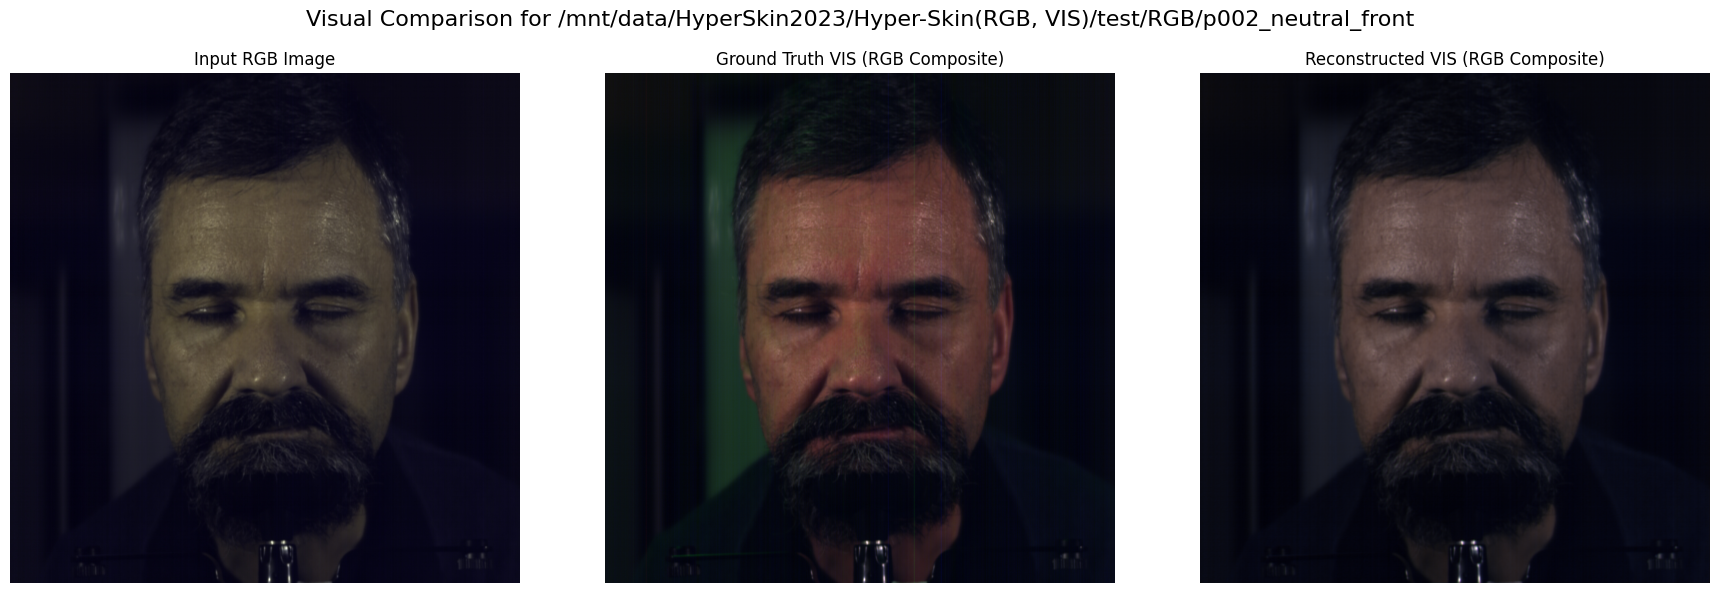

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f'Visual Comparison for {filename}', fontsize=16)

# 1. Plot Original Input RGB Image
axs[0].imshow(x.permute(1, 2, 0).numpy())
axs[0].set_title('Input RGB Image')
axs[0].axis('off')

# 2. Plot Original VIS Image (as RGB composite)
axs[1].imshow(gt_vis_rgb)
axs[1].set_title('Ground Truth VIS (RGB Composite)')
axs[1].axis('off')

# 3. Plot Reconstructed VIS Image
axs[2].imshow(pred_vis_rgb)
axs[2].set_title('Reconstructed VIS (RGB Composite)')
axs[2].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Error Map
Plots absolute error maps to highlight where the model performs poorly on the selected sample.

MAE on RGB Composite:
Dark -> Dark Red = Low Error

Bright Yellow -> White = High Error

Per Pixel SAM:
Purple -> Dark Blue = Low angular error

Yellow -> Green = High angular error

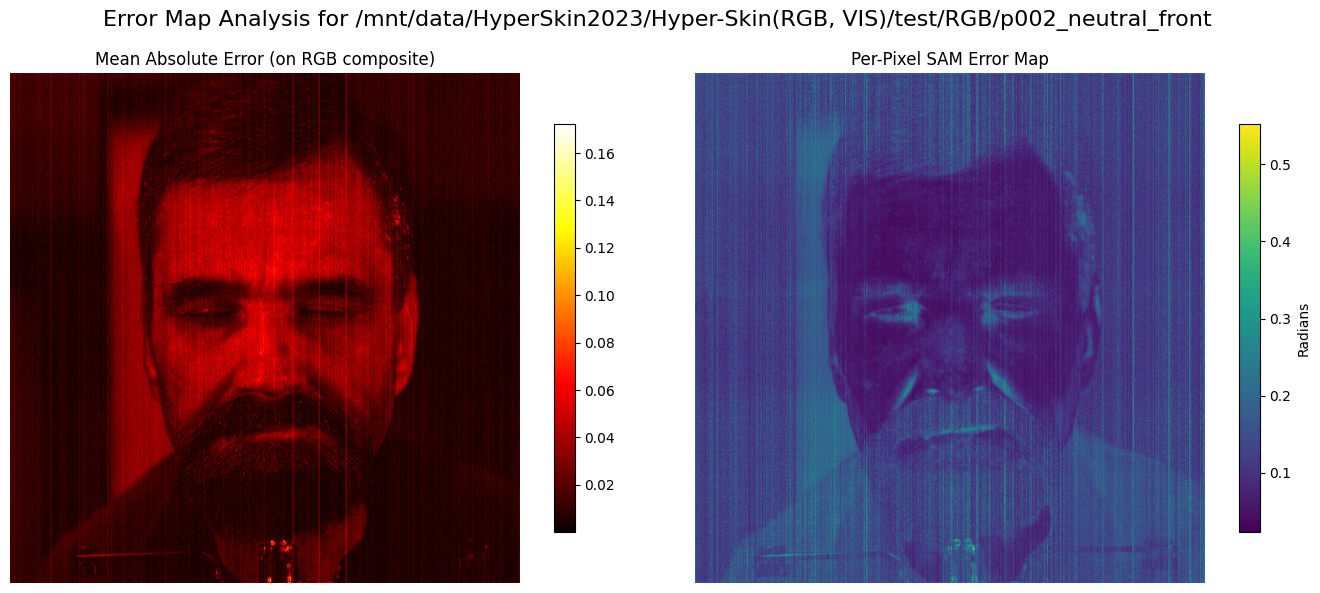

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'Error Map Analysis for {filename}', fontsize=16)

# 1. Absolute Error Map
abs_error = np.mean(np.abs(gt_vis_rgb - pred_vis_rgb), axis=2)
im1 = axs[0].imshow(abs_error, cmap='hot')
axs[0].set_title('Mean Absolute Error (on RGB composite)')
axs[0].axis('off')
fig.colorbar(im1, ax=axs[0], shrink=0.8)

# 2. Per-Pixel SAM Error Map
sam_map_flat = results["sam_map"][sample_idx].squeeze()
H, W = y.shape[1], y.shape[2]
sam_map_2d = sam_map_flat.reshape(H, W)
im2 = axs[1].imshow(sam_map_2d, cmap='viridis')
axs[1].set_title('Per-Pixel SAM Error Map')
axs[1].axis('off')
fig.colorbar(im2, ax=axs[1], shrink=0.8, label='Radians')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Spectral Profile

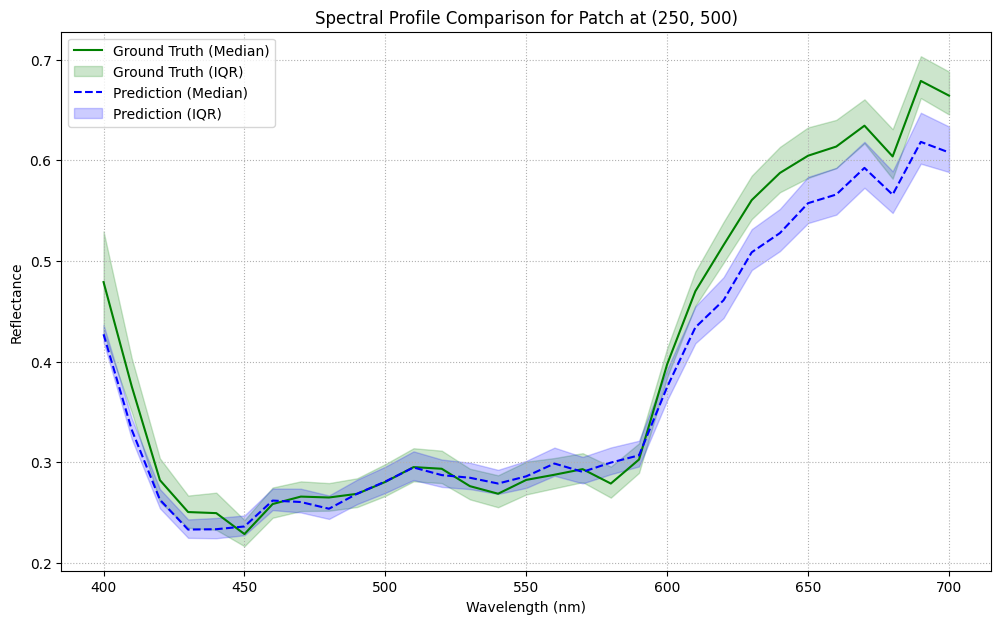

In [9]:
h, w, hwsize = 250, 500, 100
yy = y[:, h:h+hwsize, w:w+hwsize].reshape(y.shape[0], -1)
pp = p[:, h:h+hwsize, w:w+hwsize].reshape(p.shape[0], -1)

yy_median, yy_min, yy_max = np.median(yy, axis=1), np.percentile(yy, 25, axis=1), np.percentile(yy, 75, axis=1)
pp_median, pp_min, pp_max = np.median(pp, axis=1), np.percentile(pp, 25, axis=1), np.percentile(pp, 75, axis=1)

plt.figure(figsize=(12, 7))
plt.plot(BAND_WAVELENGTHS, yy_median, 'g-', label='Ground Truth (Median)')
plt.fill_between(BAND_WAVELENGTHS, yy_min, yy_max, color='g', alpha=0.2, label='Ground Truth (IQR)')

plt.plot(BAND_WAVELENGTHS, pp_median, 'b--', label='Prediction (Median)')
plt.fill_between(BAND_WAVELENGTHS, pp_min, pp_max, color='b', alpha=0.2, label='Prediction (IQR)')

plt.title(f'Spectral Profile Comparison for Patch at ({h}, {w})')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Reflectance')
plt.legend()
plt.grid(True, linestyle=':')
plt.show()

# Distribution of Performance Scores

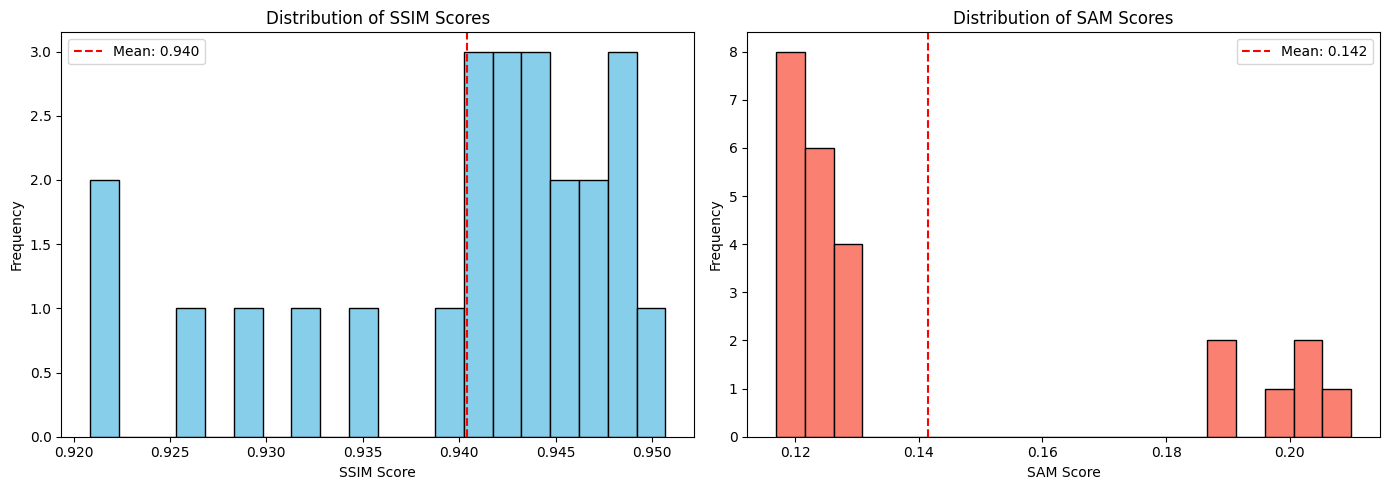

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].hist(ssim_scores, bins=20, color='skyblue', edgecolor='black')
axs[0].set_title('Distribution of SSIM Scores')
axs[0].set_xlabel('SSIM Score')
axs[0].set_ylabel('Frequency')
axs[0].axvline(ssim_scores.mean(), color='r', linestyle='--', label=f'Mean: {ssim_scores.mean():.3f}')
axs[0].legend()

axs[1].hist(sam_scores, bins=20, color='salmon', edgecolor='black')
axs[1].set_title('Distribution of SAM Scores')
axs[1].set_xlabel('SAM Score')
axs[1].set_ylabel('Frequency')
axs[1].axvline(sam_scores.mean(), color='r', linestyle='--', label=f'Mean: {sam_scores.mean():.3f}')
axs[1].legend()

plt.tight_layout()
plt.show()

# Visualizing SSIM Error for Each Spectral Band

Show which wavelengths that is predicted well vs poorly.

White areas = High SSIM

Dark Areas = Low SSIM

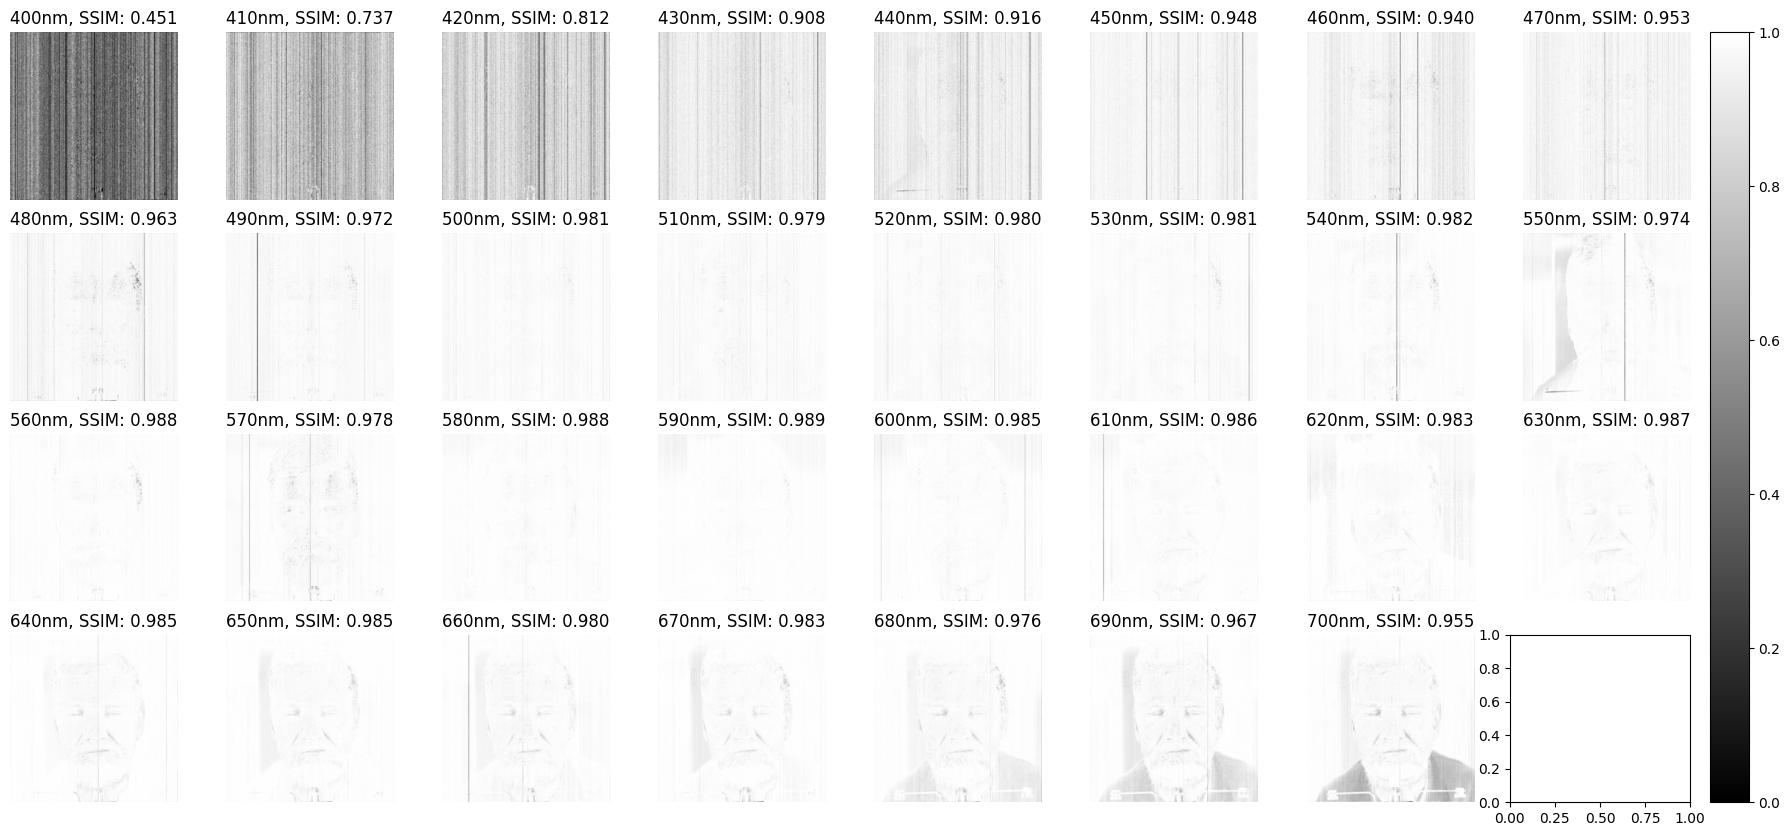

In [11]:
band_31 = np.arange(400, 710, 10)
ssim_map = np.array(results["ssim_map"]).squeeze()
fig, axes = plt.subplots(nrows=4, ncols=8, figsize=(26, 10))
for i, ax in enumerate(axes.flat[:-1]):
    im = ax.imshow(ssim_map[6, i, :, :], vmin=0, vmax=1, cmap='gray')
    ax.axis('off')
    ax.set_title(f"{band_31[i]}nm, SSIM: {ssim_map[6, i, :, :].mean():.3f}")
fig.colorbar(im, ax=axes.ravel().tolist(), pad = 0.01)
plt.show()

# Visualizing SAM Error Across All Test Samples

White/bright areas = High SAM error (bad)

Black/dark areas = Low SAM error (good)

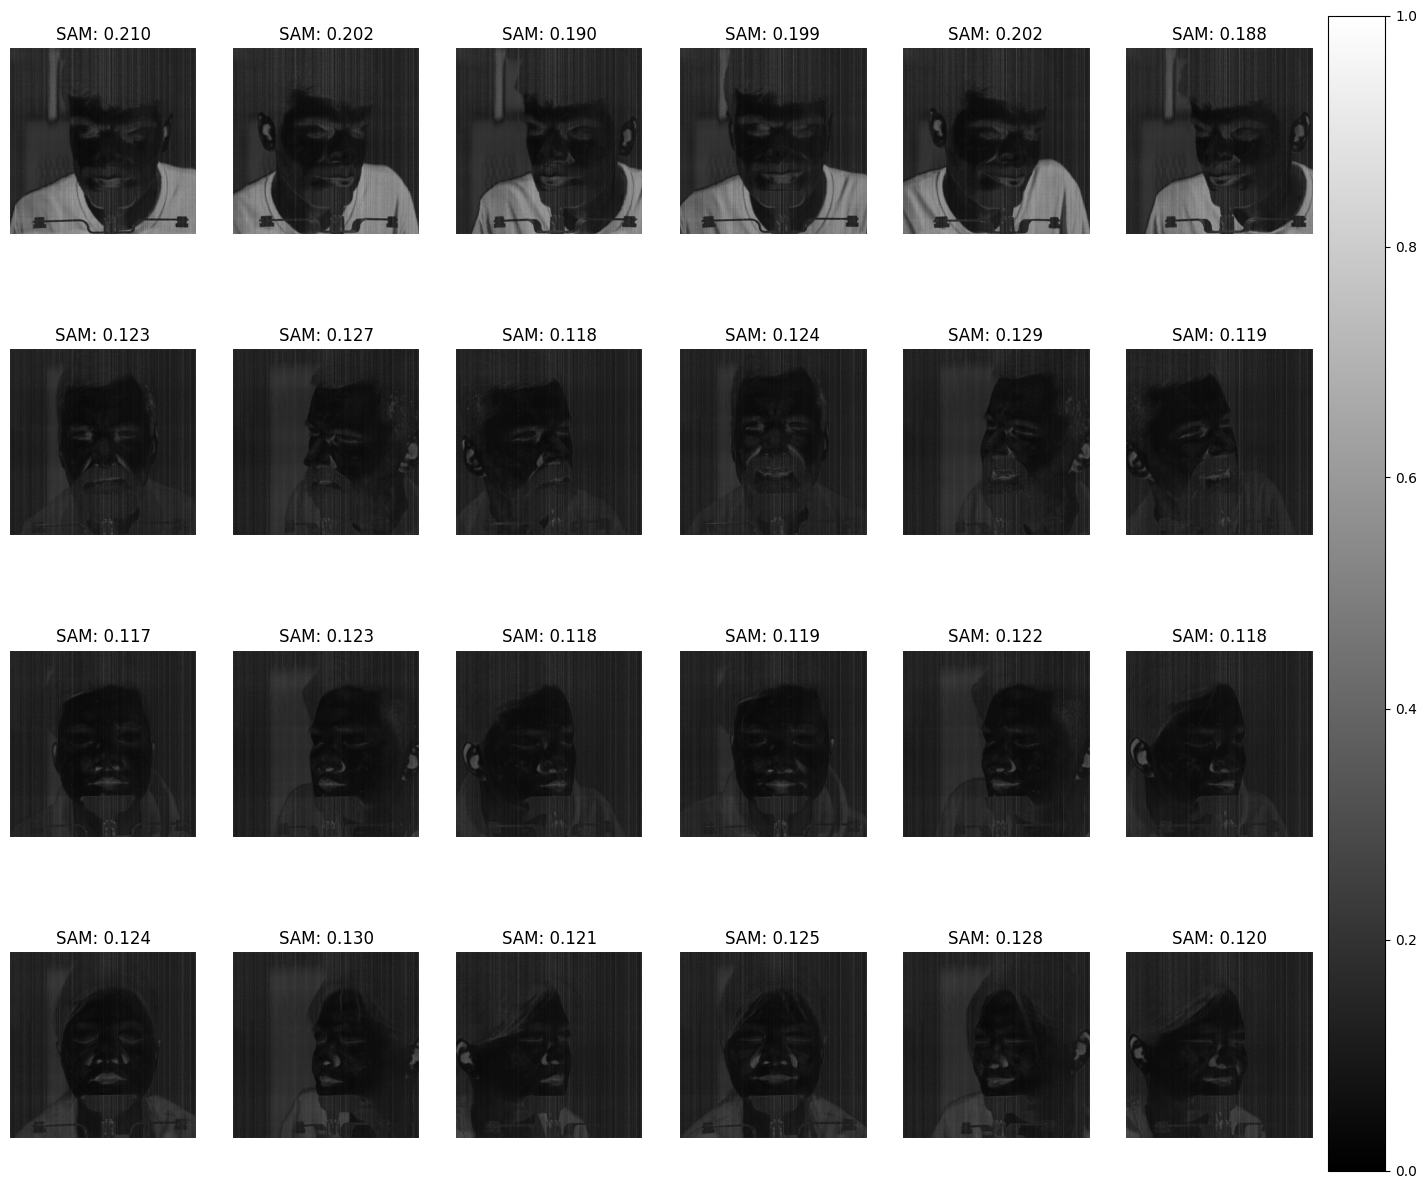

In [12]:
sam_map = np.array(results["sam_map"]).squeeze()

fig, axes = plt.subplots(4, 6, figsize=(20, 15))
axes = axes.flatten()

for img, ax in zip(sam_map, axes):
    im = ax.imshow(img, vmin=0, vmax=1, cmap='gray')
    ax.axis('off')
    ax.set_title(f"SAM: {img.mean():.3f}")

for ax in axes[len(sam_map):]:
    ax.axis('off')

fig.colorbar(im, ax=axes.tolist(), pad=0.01)
plt.show()

# Old Cells. Ignore 

In [ ]:
from __future__ import absolute_import, division, print_function

%load_ext autoreload
%reload_ext autoreload
%autoreload 2

Evaluation:
1. Evaluate on the pretrained models: download the pretrained model [here](https://drive.google.com/drive/folders/1G1GOA0FthtmOERJIJ0pALOSgXc6XOfoY) (credit: caiyuanhao)
2. Evaluate on the models retrained with Hyper-Skin data: 
3. Do step 1-2 for (RGB, VIS) data, and only step 2 for (MSI, NIR) data (reason, all pretrained model is based on input with in_channels = 3)
4. For all, compute the SSIM (for spatial evaluation) and SAM (for spectral evaluation)

In [ ]:
import sys
import os

project_root = os.path.abspath('..')

if project_root not in sys.path:
    sys.path.append(project_root)

print(f"Added to path: {project_root}")

In [ ]:
import os 
import cv2 
import pickle
import spectral
import spectral.io.envi as envi
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import torch
from torchvision import transforms
from torchmetrics import SpectralAngleMapper, StructuralSimilarityIndexMeasure

from hsiData import HyperSkinData
from helpers import metrics 
from hsiData.models.reconstruction import MST_Plus_Plus, HSCNN_Plus, hrnet

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

In [ ]:
data_dir = '/mnt/data/HyperSkin2023'
rgbvis_dir = f'{data_dir}/Hyper-Skin(RGB, VIS)'
# mask_dir = f'{data_dir}/mask'
pretrained_dir  = '/home/gabriel/Hyper-Skin-2023/Models/RGB-VIS'

# directories to the test data 
rgb_dir = f'{rgbvis_dir}/test/RGB'
vis_dir = f'{rgbvis_dir}/test/VIS'
# mask_dir = f'{mask_dir}/test'

# directory to save the results
results_dir = '/home/gabriel/Hyper-Skin-2023/evaluationResults'
if not os.path.exists(results_dir):
    os.mkdir(results_dir)

In [ ]:
test_transform = transforms.Compose([
        transforms.ToTensor()
    ])
test_dataset = HyperSkinData.Load(
            hsi_dir = vis_dir,
            rgb_dir = rgb_dir, 
            transform = test_transform
    )
test_loader = torch.utils.data.DataLoader(
                                    dataset = test_dataset, 
                                    batch_size = 1, 
                                    shuffle = False,
                                    pin_memory = False)

1. Evaluation: MST_Plus_Plus (Pretrained on NTIRE)

In [ ]:
# load the pretrained model from NTIRE 
model = MST_Plus_Plus.MST_Plus_Plus(in_channels=3, out_channels=31, n_feat=31, stage=3)
checkpoint = torch.load(f'{pretrained_dir}/MSTPP-RGBVIS.pt')
model.load_state_dict(checkpoint)

In [ ]:
model.to(device)
model.eval() 
results = {
    "file": [],
    "pred": [],
    "ssim_score": [],
    "ssim_map": [],
    "sam_score": [],
    "sam_map": []
}
metrics.ssim_fn.to(device)
for k, data in enumerate(test_loader):
    x, y = data 
    x, y = x.float().to(device), y.float().to(device)

    with torch.no_grad():
        pred = model(x)

    ssim_score, ssim_map = metrics.ssim_fn(pred, y)
    sam_score, sam_map = metrics.sam_fn(pred, y)

    results["file"].append(test_dataset.rgb_files[0].split('\\')[-1].split('.')[0])
    results["pred"].append(pred.cpu().detach().numpy())
    results["ssim_score"].append(ssim_score.cpu().detach().numpy())
    results["ssim_map"].append(ssim_map.cpu().detach().numpy())
    results["sam_score"].append(sam_score.cpu().detach().numpy())
    results["sam_map"].append(sam_map.cpu().detach().numpy())
    
    print(f"Test [{k}/{len(test_loader)}]: {results['file'][-1]}, SSIM: {results['ssim_score'][-1]}, SAM: {results['sam_score'][-1]}")    

# save the results in pickle format
with open(f'{results_dir}/mst_plus_plus.pkl', 'wb') as f:
    pickle.dump(results, f)

In [ ]:
# compute the mean and std of the SSIM and SAM scores
ssim_scores = np.array(results["ssim_score"])
ssim_mean = np.mean(ssim_scores)
ssim_std = np.std(ssim_scores)

sam_scores = np.array(results["sam_score"])
sam_mean = np.mean(sam_scores)
sam_std = np.std(sam_scores)
print(f"SSIM: {ssim_mean:.4f} +/- {ssim_std:.4f}")
print(f"SAM: {sam_mean:.4f} +/- {sam_std:.4f}")

In [ ]:
# visualize the ssim map for 31 bands to understand which band has better ssim score
band_31 = np.arange(400, 710, 10)
ssim_map = np.array(results["ssim_map"]).squeeze()
fig, axes = plt.subplots(nrows=4, ncols=8, figsize=(26, 10))
for i, ax in enumerate(axes.flat[:-1]):
    im = ax.imshow(ssim_map[6, i, :, :], vmin=0, vmax=1, cmap='gray')
    ax.axis('off')
    ax.set_title(f"{band_31[i]}nm, SSIM: {ssim_map[6, i, :, :].mean():.3f}")
fig.colorbar(im, ax=axes.ravel().tolist(), pad = 0.01)
plt.show()

In [ ]:
# visualize the sam map for 31 bands to understand which band has better ssim score
sam_map = np.array(results["sam_map"]).squeeze()

fig, axes = plt.subplots(4, 6, figsize=(20, 15))
axes = axes.flatten()

for img, ax in zip(sam_map, axes):
    im = ax.imshow(img, vmin=0, vmax=1, cmap='gray')
    ax.axis('off')
    ax.set_title(f"SAM: {img.mean():.3f}")

for ax in axes[len(sam_map):]:
    ax.axis('off')

fig.colorbar(im, ax=axes.tolist(), pad=0.01)
plt.show()

In [ ]:
h, w, hwsize = 250, 500, 100
x, y = test_dataset[6]
y = y.numpy()
p = np.array(results["pred"]).squeeze()[6]

yy = y[:, h:h+hwsize, w:w+hwsize].reshape(-1, 10000)
yy_median = np.median(yy, axis=1)
yy_max = yy.max(1)
yy_min = yy.min(1)
pp = p[:, h:h+hwsize, w:w+hwsize].reshape(-1, 10000)
pp_median = np.median(pp, axis=1)
pp_max = pp.max(1)
pp_min = pp.min(1)

In [ ]:
plt.imshow(x.permute(1, 2, 0).numpy())

# Add the patch to the Axes
plt.gca().add_patch(Rectangle((w,h),hwsize,hwsize,linewidth=1.2,edgecolor='r',facecolor='none'))

In [ ]:
# Plot ground-truth VIS and reconstructed VIS as 3-band (RGB) composites
import numpy as np

# band wavelengths
band_wl = np.arange(400, 710, 10)  

# pick 3 bands for R, G, B (e.g. 610, 550, 460 nm)
rgb_inds = [np.argmin(np.abs(band_wl - wl)) 
            for wl in (610, 550, 460)]

# y is GT HSI cube (31, H, W), p is your pred array (31, H, W)
gt_cube = y              # already a NumPy array from Cell 11
pr_cube = p              # likewise

def make_rgb(comp_cube, inds):
    # extract & normalize
    patch = comp_cube[inds]                         # (3, H, W)
    patch = (patch - patch.min())/(patch.max()-patch.min())
    return np.transpose(patch, (1,2,0))            # (H, W, 3)

gt_rgb = make_rgb(gt_cube, rgb_inds)
pr_rgb = make_rgb(pr_cube, rgb_inds)

fig, axs = plt.subplots(1,2, figsize=(12,6))
axs[0].imshow(gt_rgb)
axs[0].set_title('Original VIS (RGB composite)')
axs[0].axis('off')

axs[1].imshow(pr_rgb)
axs[1].set_title('Reconstructed VIS (RGB composite)')
axs[1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Absolute‐error composite
err = np.abs(gt_rgb - pr_rgb).max(axis=2)   # per-pixel max over R,G,B
plt.figure(figsize=(6,6))
plt.imshow(err, cmap='hot')
plt.colorbar(shrink=0.8)
plt.title('Absolute error (max over RGB composite)')
plt.axis('off')
plt.show()

In [ ]:
plt.plot(band_31, yy_median, label='Groud truth')
plt.fill_between(band_31, yy_min, yy_max, alpha=0.2)
plt.plot(band_31, pp_median, label='Prediction')
plt.fill_between(band_31, pp_min, pp_max, alpha=0.2)
plt.title('Spectral profile at (300, 500)')
plt.legend()
plt.ylabel('Reflectance')
plt.xlabel('Band')
plt.show()

In [ ]:
# 1) grab the raw sam‐map array for sample #6
full_sam = np.array(results["sam_map"])[6]   # e.g. shape (1, H*W) or (H*W,)

# 2) squeeze out any leading 1‐dims so you have a flat vector of length H*W
full_sam = full_sam.squeeze()               # now shape (H*W,)

# 3) figure out your spatial dims from the dataset
_, y = test_dataset[6]                       # y is (31, H, W)
H, W = y.shape[1], y.shape[2]

# 4) reshape back to 2‐D
sam_map_2d = full_sam.reshape(H, W)

# 5) plot
plt.figure(figsize=(6,6))
plt.imshow(sam_map_2d, cmap='viridis')
plt.title('SAM error per pixel')
plt.colorbar(shrink=0.8)
plt.axis('off')
plt.show()